# External Appearance Analysis — Individual Processing


*Traitly version used in this tutorial: 0.1.0*


In this tutorial, we will demonstrate how to perform external appearance analysis of fruits using `FruitExternalAnalyzer` to extract morphology and color measurements from individual images.

!!! tip "Follow along"
    :fontawesome-solid-file-code: Download the Jupyter notebook and sample image for this tutorial [here](https://github.com/mariameraz/traitly/tree/main/tutorials_data/ext_analysis_ind_img_sample).


In this tutorial, we will use photos with a white background, which is a predefined background in `FruitExternalAnalyzer.generate_fruit_mask()`, so we will not need to adjust the background color thresholds to remove it. If you need to make adjustments to remove the background, please see the [Background Segmentation](https://github.com/mariameraz/traitly/blob/main/docs/en/tutorials/background_segmentation.md) section.


First, we load the `FruitExternalAnalyzer` class from traitly and the image to be analyzed.

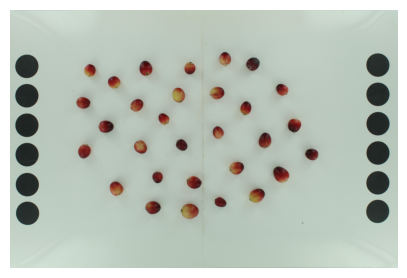

In [ ]:
from traitly.fruit_phenotyping import FruitExternalAnalyzer


path_img = '~/ext_analysis_sample1.jpg'

pic_test = FruitExternalAnalyzer(path_img)

pic_test.load_image()

Run `setup_measurements()` to detect the measurement references in the image (black circles). For more details on how this works, see the `setup_measurements` section of the [External Analyzer](https://github.com/mariameraz/traitly/blob/main/docs/en/tutorials/external.md) Class.

In [2]:
pic_test.setup_measurements()


★ LABEL DETECTION:

★ REFERENCE SIZE:
> Reference size detected:
  - Processing reference box(es) with a confidence threshold >=0.6:
            Ref 1: 452x2534 px, conf: 0.951
            Ref 2: 450x2551 px, conf: 0.943

  - Total circles detected: 12
            Range: [310.2, 314.1] px
            Filtered circles: 11/12 (std > 2)

        . ݁₊ ⊹ . ݁ ⟡ ݁ px/cm density: 124.9 (diameter_cm: 2.5 cm) ⟡ ݁ . ⊹ ₊ ݁.

Note: Default reference diameter (2.5 cm) applied.
        Specify diameter_cm to override this value.


Now let's generate the fruit masks with `generate_fruit_mask()` using the default white background parameters and see which objects in the image were detected as fruits with `detect_fruits()`.

As we can see in the plots generated below, the masks of some fruits have unfilled spaces and poorly defined contours. Additionally, some fruits were not detected (they don't have the green contour). We need to modify some parameters to improve both the masks and the detection, let's address that below.

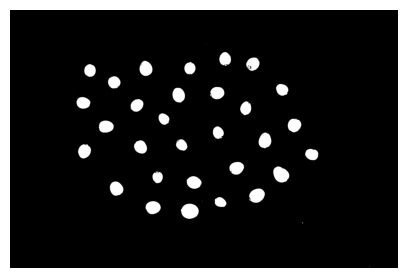

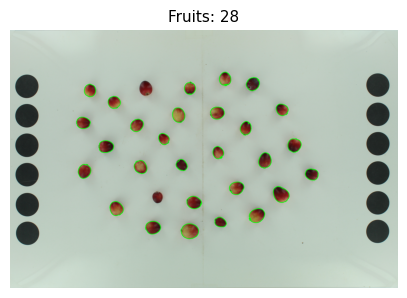


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 28 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.5
        - min_fruit_area: 500


In [3]:
pic_test.generate_fruit_mask(background_color='white')

pic_test.detect_fruits(
    plot=True, plot_size=(5,5),
    contour_thickness=7,
) 

In `generate_fruit_mask()`, the fruit masks were improved by applying `apply_convex_hull=True`, which ensures that fruits have a smooth and closed contour. The `kernel_blur=5` parameter also helps to better define the fruit contours. Having a good definition of fruit contours is paramount since calculations are based on this, and any holes that might exist in the fruit mask are automatically removed by being enclosed within the contour of the entire fruit. Applying `erosion_px=1` removes some pixels from the fruit contour, which helps eliminate parts of the fruit that reflect the background color, as well as portions of the background that might be included in the mask as part of the fruit and could skew the fruit color estimates.

In `detect_fruits()`, `min_fruit_circularity=0.4` ensures that we capture all fruits by lowering the circularity threshold, since some fruits are not very circular.

See the [External Analyzer Class](https://github.com/mariameraz/traitly/blob/main/docs/en/tutorials/external.md) for more details on how `generate_fruit_mask()` and `detect_fruits()` work and their available arguments.

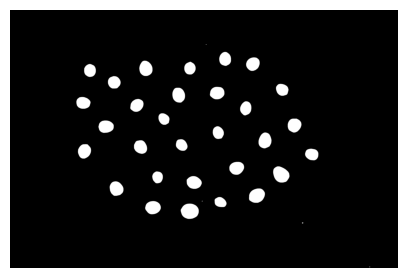

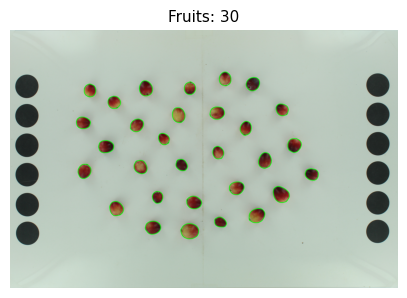


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 30 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.4
        - min_fruit_area: 500


In [4]:
pic_test.generate_fruit_mask(background_color='white',
                             apply_convex_hull=True,
                             kernel_blur=5,
                             erosion_px=1)

pic_test.detect_fruits(
    plot=True, plot_size=(5,5),
    contour_thickness=7,
    min_fruit_circularity=0.4
)

Now that the fruits have been correctly detected and segmented, we can perform the morphological and color analyses.


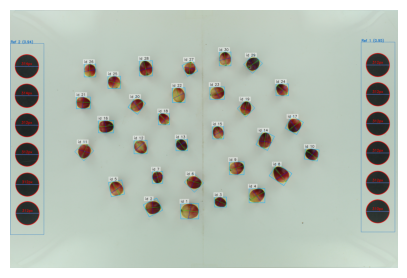

In [5]:
pic_test.analyze_morphology(display_table=False,
                            plot=True,
                            plot_size=(5,5))

pic_test.analyze_color(display_table=False,
                       plot=False)

When `analyze_morphology()` and `analyze_color()` are run, `save_all()` will save a CSV file with the results of each analysis and an annotated image. In the annotated image, which can be generated by either the morphological or color analysis, we can verify that both the fruits and references have been correctly detected.

In [ ]:
pic_test.results.save_all()

Finally, you can save the parameters and session information from your analysis with `save_parameters()` to ensure reproducibility of your future analyses or to use them in batch processing.

In [ ]:
pic_test.save_parameters()